In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/Flight_Booking.csv')

In [4]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [6]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [7]:
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [69]:
df.shape

(300153, 11)

In [8]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [10]:
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

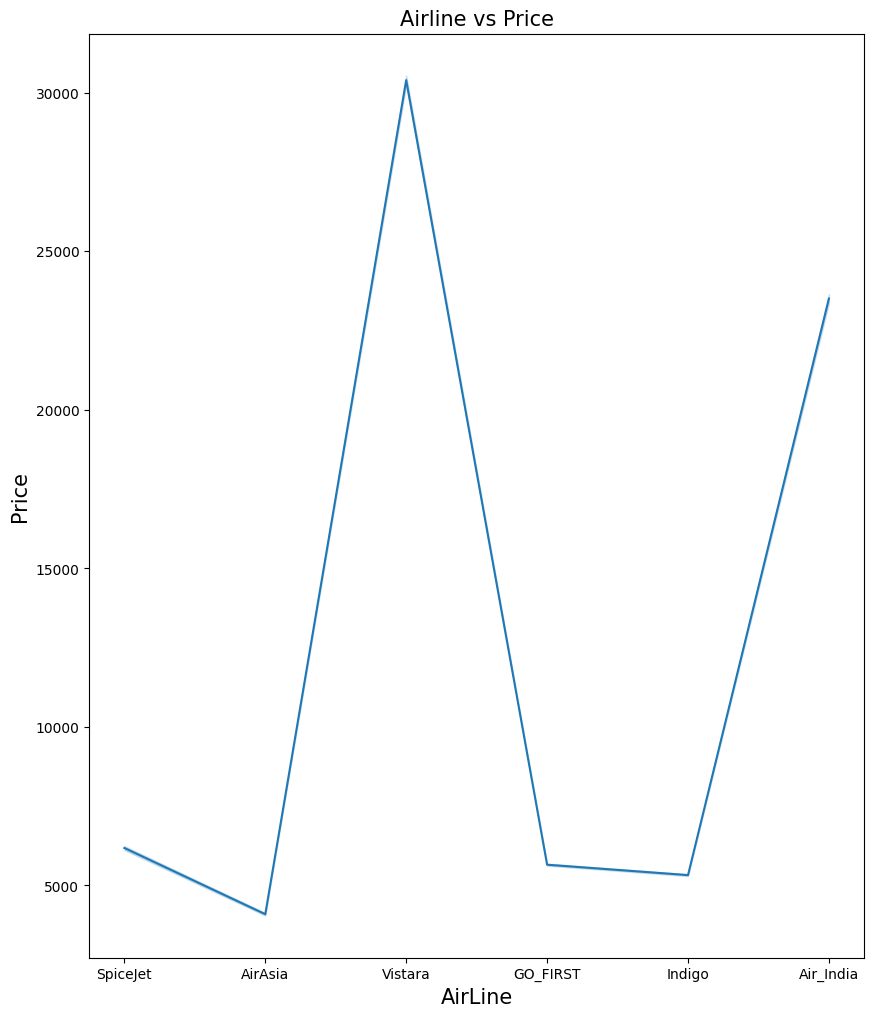

In [15]:
plt.figure(figsize=(10,12))
sns.lineplot(data=df,x=df['airline'],y=df['price'])
plt.title('Airline vs Price',fontsize=15)
plt.xlabel('AirLine',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

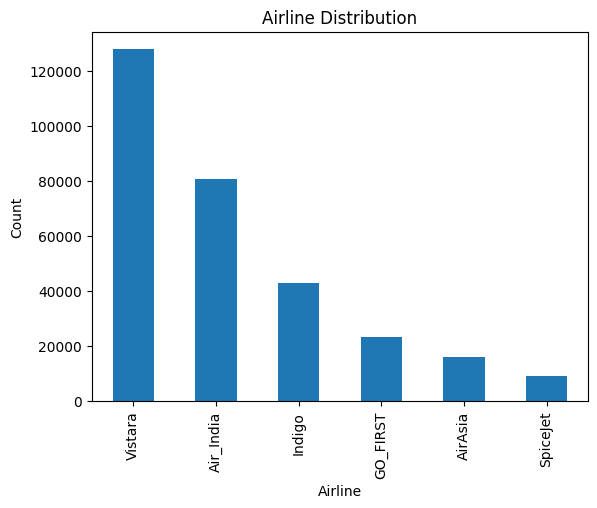

In [16]:
df['airline'].value_counts().plot(kind='bar')
plt.title('Airline Distribution')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

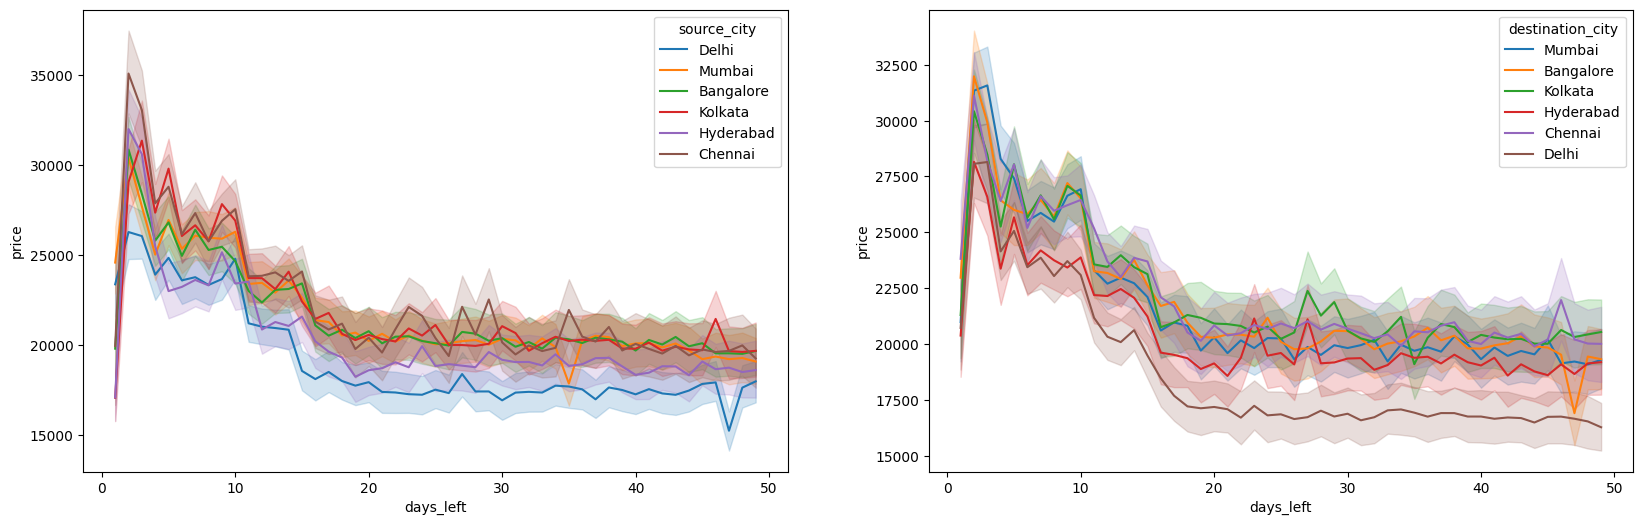

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
sns.lineplot(x='days_left', y='price', data=df, hue='source_city', ax=ax[0])
sns.lineplot(x='days_left', y='price', data=df, hue='destination_city', ax=ax[1])
plt.show()

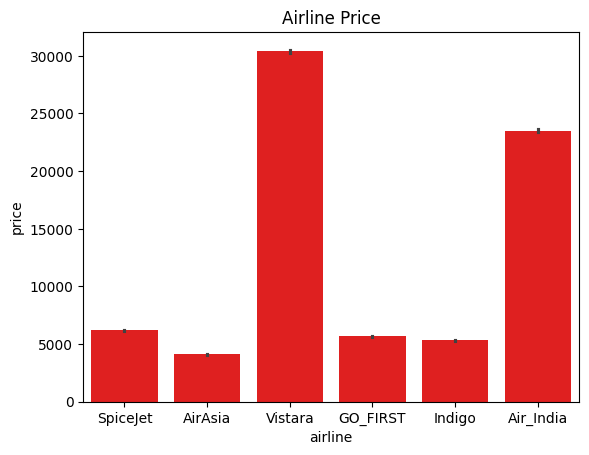

In [18]:
sns.barplot(x='airline',y='price',data=df,color='red')
plt.title('Airline Price')
plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [21]:
le = LabelEncoder()

In [22]:
df["airline"] = le.fit_transform(df["airline"])
df["source_city"] = le.fit_transform(df["source_city"])
df["departure_time"] = le.fit_transform(df["departure_time"])
df["stops"] = le.fit_transform(df["stops"])
df["arrival_time"] = le.fit_transform(df["arrival_time"])
df["destination_city"] = le.fit_transform(df["destination_city"])
df["class"] = le.fit_transform(df["class"])

In [23]:
X = df.drop(columns=['price', 'flight'],axis=1)
y = df['price']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
sc = StandardScaler()

In [26]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [27]:
lr = LinearRegression()

In [28]:
lr.fit(X_train,y_train)

LinearRegression()

In [29]:
y_pred = lr.predict(X_test)

In [30]:
difference = pd.DataFrame(np.c_[y_test, y_pred], columns=["Actual_Value", "Predicted_Value"])
print(difference)

       Actual_Value  Predicted_Value
0            7366.0      4585.880510
1           64831.0     52842.077073
2            6195.0      7877.980184
3           60160.0     56120.138579
4            6578.0      6663.204177
...             ...              ...
60026        5026.0      5829.230618
60027        3001.0       539.222230
60028        6734.0      5848.965500
60029        5082.0     -1498.061918
60030       66465.0     58762.406345

[60031 rows x 2 columns]


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

In [33]:
r2 = r2_score(y_test,y_pred)

In [34]:
print(f'you r2_score = {r2}')

you r2_score = 0.904554350718816


In [35]:
mae = mean_absolute_error(y_test,y_pred)

In [36]:
print(f'you mean abs error = {mae}')

you mean abs error = 4624.994868016881


<Axes: >

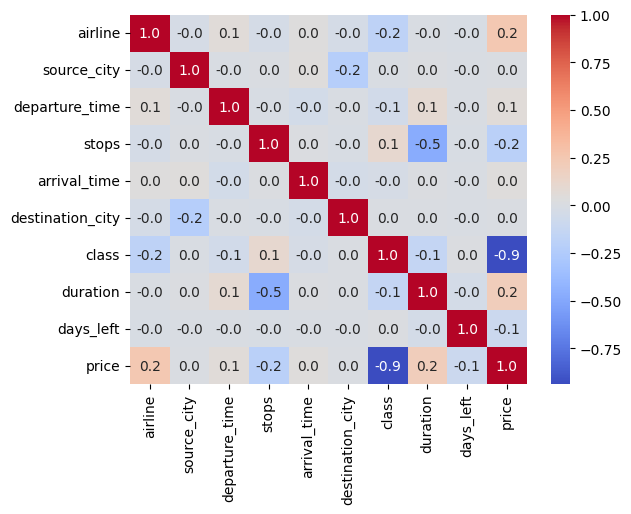

In [41]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='1.1f')

In [42]:
from sklearn.tree import DecisionTreeRegressor

In [43]:
dtr = DecisionTreeRegressor()

In [44]:
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

In [45]:
y_pred_new = dtr.predict(X_test)

In [46]:
r2 = r2_score(y_test, y_pred_new)
print(f'R-squared: {r2}')

R-squared: 0.9754694694544452


In [47]:
mean_abs_error = mean_absolute_error(y_test, y_pred_new)
print(f'Mean Absolute Error (MAE): {mean_abs_error}')

Mean Absolute Error (MAE): 1175.287357087727


In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [49]:
rfr = RandomForestRegressor()

In [50]:
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [51]:
y_pred_rfr = rfr.predict(X_test)

In [52]:
r2 = r2_score(y_test, y_pred_rfr)
print(f'R-squared: {r2}')

R-squared: 0.9849493875669985


In [56]:
mse = mean_squared_error(y_test,y_pred_rfr)
print(f'mean_sqaure_error: {mse}')

mean_sqaure_error: 7758323.915567567
